# 제조 AI 1주차


## Step 1: Colab 시작

In [9]:
print("제조AI 프로젝트 시작!")

제조AI 프로젝트 시작!


In [10]:
import sys

print(sys.version)
import numpy as np 
import pandas as pd

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)

3.11.17 (main, Oct  1 2026, 20:09:52) [Clang 20.1.8 ]
numpy version: 2.4.6
pandas version: 3.0.6


## Step 2: Numpy

In [11]:

temp = np.array([201.5, 203.2, 198.7, 205.1, 202.4]) # 사출기 금형온도 5회 측정(°C)
print(temp.shape) #(5,) 데이터의 “모양”부터 읽는 습관
print(temp.dtype) # float64 자료형
print(temp * 1.8 + 32) # 전체를 화씨로 반복문 없이 한 번에(벡터 연산)

(5,)
float64
[394.7  397.76 389.66 401.18 396.32]


In [12]:
print(temp.mean(), temp.std()) # 평균 202.18, 표준편차 ≈ 2.15
print(temp.min(), temp.max()) # 198.7 ~ 205.1 범위 확인
sensors = np.array([[201.5, 85.2], [203.2, 84.8], [198.7, 86.1]]) # 3회 ×(온도, 압력)
print(sensors.shape) #(3, 2) 행=측정, 열=변수
print(sensors.mean(axis=0)) # 열 방향 평균 → 변수별 평균 [201.13, 85.37]

202.18 2.1065611787935343
198.7 205.1
(3, 2)
[201.13333333  85.36666667]


## Step 3: Pandas

In [ ]:
df= pd.DataFrame({
'machine': ['M1','M1','M2','M2','M3','M3','M1','M2'], # 설비
'temp': [201.5, 203.2, 198.7, 205.1, 202.4, 199.8, 204.0, 197.5],
'pressure': [85.2, 84.8, 86.1, 83.9, 85.5, 86.4, 84.1, 86.8],
'defect': [0, 0, 1, 0, 0, 1, 0, 1] # 불량 여부(0=정상, 1=불량)
})
df.head() # 표의 앞부분 미리보기

,machine,temp,pressure,defect
0,M1,201.5,85.2,0
1,M1,203.2,84.8,0
2,M2,198.7,86.1,1
3,M2,205.1,83.9,0
4,M3,202.4,85.5,0


In [31]:
# df= pd.read_csv('process.csv') # 실제 데이터가 있다면 이렇게 불러오기
df.info() # 데이터프레임의 행·열 수, 열 이름, 자료형, 결측치 여부 확인 
df.describe() # 수치형 열의 통계 요약(평균, 표준편차, 최소/최대값 등) 확인 

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   machine   8 non-null      str    
 1   temp      8 non-null      float64
 2   pressure  8 non-null      float64
 3   defect    8 non-null      int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 388.0 bytes


,temp,pressure,defect
count,8.00000,8.000000,8.000000
mean,201.52500,85.350000,0.375000
std,2.66284,1.054243,0.517549
min,197.50000,83.900000,0.000000
25%,199.52500,84.625000,0.000000
50%,201.95000,85.350000,0.000000
75%,203.40000,86.175000,1.000000
max,205.10000,86.800000,1.000000


In [23]:
print(df['temp']) # 열 선택
print(df[['machine','defect']]) # 열 선택

0    201.5
1    203.2
2    198.7
3    205.1
4    202.4
5    199.8
6    204.0
7    197.5
Name: temp, dtype: float64
  machine  defect
0      M1       0
1      M1       0
2      M2       1
3      M2       0
4      M3       0
5      M3       1
6      M1       0
7      M2       1


In [24]:
print(df.iloc[0:3]) # 행 선택
print(df[df['defect']==1]) # 조건에 맞는 행 선택
print(df[(df['defect']==1) & (df['temp'] < 200)]) # 여러 조건에 맞는 행 선택

  machine   temp  pressure  defect
0      M1  201.5      85.2       0
1      M1  203.2      84.8       0
2      M2  198.7      86.1       1
  machine   temp  pressure  defect
2      M2  198.7      86.1       1
5      M3  199.8      86.4       1
7      M2  197.5      86.8       1
  machine   temp  pressure  defect
2      M2  198.7      86.1       1
5      M3  199.8      86.4       1
7      M2  197.5      86.8       1


In [33]:
print(df)

df.groupby('machine')['defect'].mean() # 설비별 불량 건수·비율 확인

  machine   temp  pressure  defect
0      M1  201.5      85.2       0
1      M1  203.2      84.8       0
2      M2  198.7      86.1       1
3      M2  205.1      83.9       0
4      M3  202.4      85.5       0
5      M3  199.8      86.4       1
6      M1  204.0      84.1       0
7      M2  197.5      86.8       1


machine
M1    0.000000
M2    0.666667
M3    0.500000
Name: defect, dtype: float64

In [41]:
df2 = df.copy() # df를 복사하여 df2 생성

df2.loc[1,'pressure'] = np.nan # 센서 미수신 상황을 재현 
print(df2) # 결측치 확인
print(df2.isna().sum())  # 열별 결측치 개수 확인
print(df2['pressure'].mean()) # NaN을 제외한 평균 계산

  machine   temp  pressure  defect
0      M1  201.5      85.2       0
1      M1  203.2       NaN       0
2      M2  198.7      86.1       1
3      M2  205.1      83.9       0
4      M3  202.4      85.5       0
5      M3  199.8      86.4       1
6      M1  204.0      84.1       0
7      M2  197.5      86.8       1
machine     0
temp        0
pressure    1
defect      0
dtype: int64
85.42857142857143


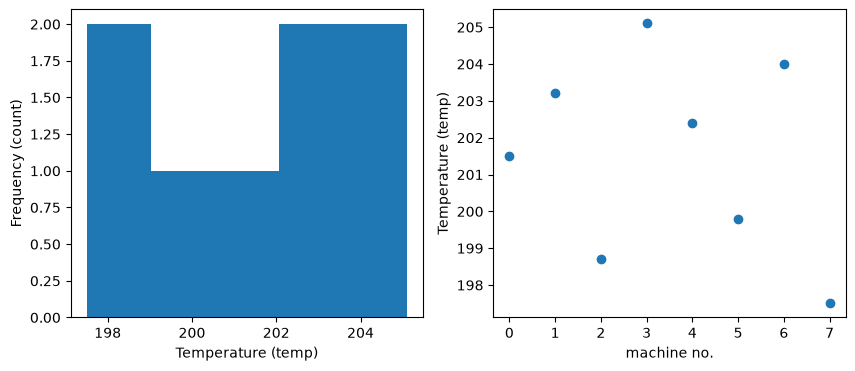

In [52]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # 1행 2열의 서브플롯 생성
axes[0].hist(df["temp"], bins=5) # 온도 분포 히스토그램
axes[0].set_xlabel("Temperature (temp)")
axes[0].set_ylabel("Frequency (count)") 
axes[1].scatter(range(len(df)), df["temp"].values, marker='o') # 각 설비별 온도 산점도
axes[1].set_xlabel("machine no.")
axes[1].set_ylabel("Temperature (temp)")

plt.show() 

## 과제 
제조 AI 적용 사례 조사 

제조 산업에서 AI 실제로 적용된 사례를 조사하고, 
주요 내용을 1장으로 요약하여 제출하세요.

제출 형식: PDF 
반드시 참고한 자료의 출처를 명시하세요.
